# PowerCo 고객 이탈 예측 데이터 구축 — v13

## 프로젝트 주제

2015년 12월 31일까지 확보된 고객·계약·소비·가격 정보를 사용해  
**2016년 1월 1일부터 3월 31일까지 향후 3개월 내 고객 이탈 여부를 예측하기 위한 학습 데이터를 구축**한다.

분석 단위는 고객 1명이며, `client_data`의 고객 정보와 `price_data`의 월별 가격 이력을 고객 단위로 집계해 결합한다.

## 이 노트북의 범위

이 파일은 모든 모델에 공통으로 사용하는 데이터 구축 과정만 수행한다.

1. 데이터 로드와 스키마 확인
2. 고객 기준 Train/Test 분할
3. Train EDA
4. 예측 기준일 및 누수 점검
5. 검증된 파생변수 생성
6. 고객 단위 병합
7. 명백한 중복 제거
8. 범주형은 원본 상태로 `train.csv`, `test.csv` 저장

다음 작업은 모델마다 필요한 방식이 다르므로 이 파일에서 수행하지 않는다.

- 결측치 대체
- 원-핫 인코딩
- StandardScaler
- PCA
- 클래스 불균형 처리
- 모델 학습 및 하이퍼파라미터 탐색

이 작업들은 이후 모델링 노트북의 교차검증 Pipeline 안에서 실행한다.

## 실행 환경 설정

In [1]:
from pathlib import Path
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import Rectangle
from IPython.display import display
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.rcParams["figure.figsize"] = (7, 3.8)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titleweight"] = "bold"


def set_korean_font():
    candidates = [
        "Noto Sans CJK KR",
        "NanumGothic",
        "Malgun Gothic",
        "AppleGothic",
        "Arial Unicode MS",
    ]
    available = {font.name for font in font_manager.fontManager.ttflist}

    for font_name in candidates:
        if font_name in available:
            plt.rcParams["font.family"] = font_name
            print(f"사용 글꼴: {font_name}")
            return font_name

    print("한글 폰트를 찾지 못했습니다. 그래프에서 한글이 깨질 수 있습니다.")
    return None


KOREAN_FONT = set_korean_font()

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("현재 실행 폴더:", Path.cwd())

사용 글꼴: Malgun Gothic
Python: 3.12.13
pandas: 3.0.3
numpy: 2.4.6
현재 실행 폴더: C:\SKN_AI\SKN33_2_4team_project\preprocessing


# 1. 데이터 로드와 스키마 확인

분할 전에 전체 데이터에서 확인하는 것은 **파일 로드, 컬럼, 자료형, 기본키, 두 파일의 고객 모집단 관계**처럼  
타깃과 무관한 구조적 사항으로 제한한다.

분포, 이탈률, 변수 선택에 영향을 주는 상세 EDA는 Train/Test 분할 후 Train에서만 수행한다.

In [2]:
# 현재 폴더와 상위 폴더에서 data/raw를 자동 탐색
DATA_DIR_CANDIDATES = [
    Path.cwd() / "data" / "raw",
    Path.cwd().parent / "data" / "raw",
]

DATA_DIR = next(
    (
        path
        for path in DATA_DIR_CANDIDATES
        if (path / "client_data.csv").exists()
        and (path / "price_data.csv").exists()
    ),
    None,
)

if DATA_DIR is None:
    checked_paths = "\n".join(
        f"- {path.resolve()}"
        for path in DATA_DIR_CANDIDATES
    )
    raise FileNotFoundError(
        "client_data.csv와 price_data.csv를 찾을 수 없습니다.\n"
        "확인한 data/raw 경로:\n"
        f"{checked_paths}"
    )

CLIENT_PATH = DATA_DIR / "client_data.csv"
PRICE_PATH = DATA_DIR / "price_data.csv"

client = pd.read_csv(CLIENT_PATH)
price = pd.read_csv(PRICE_PATH)

print("선택된 데이터 폴더:", DATA_DIR.resolve())
print("client_data:", client.shape)
print("price_data :", price.shape)

선택된 데이터 폴더: C:\SKN_AI\SKN33_2_4team_project\data\raw
client_data: (14606, 26)
price_data : (193002, 8)


In [3]:
TARGET_COL = "churn"
ID_COL = "id"

client_date_cols = [
    "date_activ",
    "date_end",
    "date_modif_prod",
    "date_renewal",
]

client_categorical_cols = [
    "channel_sales",
    "origin_up",
    "has_gas",
]

client_discrete_cols = [
    "forecast_discount_energy",
    "nb_prod_act",
    "num_years_antig",
]

client_continuous_cols = [
    "cons_12m",
    "cons_gas_12m",
    "cons_last_month",
    "forecast_cons_12m",
    "forecast_cons_year",
    "forecast_meter_rent_12m",
    "forecast_price_energy_off_peak",
    "forecast_price_energy_peak",
    "forecast_price_pow_off_peak",
    "imp_cons",
    "margin_gross_pow_ele",
    "margin_net_pow_ele",
    "net_margin",
    "pow_max",
]

price_numeric_cols = [
    "price_off_peak_var",
    "price_peak_var",
    "price_mid_peak_var",
    "price_off_peak_fix",
    "price_peak_fix",
    "price_mid_peak_fix",
]

required_client_cols = {
    ID_COL,
    TARGET_COL,
    *client_date_cols,
    *client_categorical_cols,
    *client_discrete_cols,
    *client_continuous_cols,
}

required_price_cols = {
    ID_COL,
    "price_date",
    *price_numeric_cols,
}

missing_client_cols = sorted(required_client_cols - set(client.columns))
missing_price_cols = sorted(required_price_cols - set(price.columns))

if missing_client_cols or missing_price_cols:
    raise ValueError(
        "필수 컬럼이 없습니다. "
        f"client_data: {missing_client_cols}, "
        f"price_data: {missing_price_cols}"
    )

for col in client_date_cols:
    client[col] = pd.to_datetime(client[col], errors="coerce")

price["price_date"] = pd.to_datetime(price["price_date"], errors="coerce")

schema_summary = pd.DataFrame({
    "데이터": ["client_data", "price_data"],
    "행 수": [len(client), len(price)],
    "열 수": [client.shape[1], price.shape[1]],
    "고유 고객 수": [client[ID_COL].nunique(), price[ID_COL].nunique()],
})

display(schema_summary)
print("\n[client_data 자료형]")
display(client.dtypes.rename("dtype").to_frame())

print("\n[price_data 자료형]")
display(price.dtypes.rename("dtype").to_frame())

,데이터,행 수,열 수,고유 고객 수
0,client_data,14606,26,14606
1,price_data,193002,8,16096



[client_data 자료형]


,dtype
id,str
channel_sales,str
cons_12m,int64
cons_gas_12m,int64
cons_last_month,int64
date_activ,datetime64[us]
date_end,datetime64[us]
date_modif_prod,datetime64[us]
date_renewal,datetime64[us]
forecast_cons_12m,float64



[price_data 자료형]


,dtype
id,str
price_date,datetime64[us]
price_off_peak_var,float64
price_peak_var,float64
price_mid_peak_var,float64
price_off_peak_fix,float64
price_peak_fix,float64
price_mid_peak_fix,float64


In [4]:
# 모델 분할 전에 반드시 보장해야 하는 기본키 품질
key_check = pd.DataFrame({
    "데이터": ["client_data", "price_data"],
    "전체 행 중복": [
        int(client.duplicated().sum()),
        int(price.duplicated().sum()),
    ],
    "기본키 중복": [
        int(client.duplicated(subset=[ID_COL]).sum()),
        int(price.duplicated(subset=[ID_COL, "price_date"]).sum()),
    ],
    "기본키": [
        ID_COL,
        f"{ID_COL} + price_date",
    ],
})

display(key_check)

if client.duplicated(subset=[ID_COL]).any():
    raise ValueError("client_data의 고객 ID가 중복되어 있습니다.")

if price.duplicated(subset=[ID_COL, "price_date"]).any():
    raise ValueError("price_data의 id + price_date가 중복되어 있습니다.")

# 타깃이 존재하는 client_data 고객만 분석 모집단으로 사용
client_ids = set(client[ID_COL])
price_ids = set(price[ID_COL])

id_relation = pd.DataFrame({
    "항목": [
        "client_data 고유 고객",
        "price_data 고유 고객",
        "client_data에만 존재",
        "price_data에만 존재",
        "두 데이터에 모두 존재",
    ],
    "고객 수": [
        len(client_ids),
        len(price_ids),
        len(client_ids - price_ids),
        len(price_ids - client_ids),
        len(client_ids & price_ids),
    ],
})

display(id_relation)

price_model = (
    price.loc[price[ID_COL].isin(client_ids)]
    .copy()
    .sort_values([ID_COL, "price_date"])
)

if set(price_model[ID_COL]) != client_ids:
    missing_price_customers = len(client_ids - set(price_model[ID_COL]))
    raise ValueError(
        f"가격 이력이 없는 client_data 고객이 {missing_price_customers}명 있습니다."
    )

,데이터,전체 행 중복,기본키 중복,기본키
0,client_data,0,0,id
1,price_data,0,0,id + price_date


,항목,고객 수
0,client_data 고유 고객,14606
1,price_data 고유 고객,16096
2,client_data에만 존재,0
3,price_data에만 존재,1490
4,두 데이터에 모두 존재,14606


# 2. 고객 기준 Train/Test 분할

고객을 먼저 분할한 뒤, 동일 고객의 모든 월별 가격 기록을 같은 데이터셋으로 보낸다.  
분할 이후 Test는 최종 평가용으로 봉인하고, 분포 확인이나 변수 선택에 사용하지 않는다.

In [5]:
TEST_SIZE = 0.20
RANDOM_STATE = 42

X = client.drop(columns=[TARGET_COL]).copy()
y = client[TARGET_COL].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

train_client = X_train.copy()
train_client[TARGET_COL] = y_train
train_client = (
    train_client
    .reindex(columns=client.columns)
    .reset_index(drop=True)
)

test_client = X_test.copy()
test_client[TARGET_COL] = y_test
test_client = (
    test_client
    .reindex(columns=client.columns)
    .reset_index(drop=True)
)

train_ids = set(train_client[ID_COL])
test_ids = set(test_client[ID_COL])

train_price = (
    price_model.loc[price_model[ID_COL].isin(train_ids)]
    .copy()
    .sort_values([ID_COL, "price_date"])
    .reset_index(drop=True)
)

test_price = (
    price_model.loc[price_model[ID_COL].isin(test_ids)]
    .copy()
    .sort_values([ID_COL, "price_date"])
    .reset_index(drop=True)
)

assert train_ids.isdisjoint(test_ids)
assert len(train_client) + len(test_client) == len(client)
assert len(train_price) + len(test_price) == len(price_model)
assert set(train_price[ID_COL]) == train_ids
assert set(test_price[ID_COL]) == test_ids

split_structure = pd.DataFrame({
    "데이터": ["Train", "Test"],
    "고객 수": [len(train_client), len(test_client)],
    "가격 행 수": [len(train_price), len(test_price)],
})

display(split_structure)
print("Train/Test 고객 ID 교집합:", len(train_ids & test_ids))

,데이터,고객 수,가격 행 수
0,Train,11684,140113
1,Test,2922,35036


Train/Test 고객 ID 교집합: 0


> **Test 봉인 원칙**
>
> 아래 EDA, 파생변수 검토, 중복 판단, 상관관계 확인은 Train만 사용한다.  
> Test에는 Train에서 확정한 변환 규칙만 동일하게 적용한다.

# 3. Train EDA

이 단계에서는 Train의 데이터 품질, 타깃 불균형, 변수 분포와 이탈 간 관계를 확인한다.

- 실제 NaN과 `MISSING` 같은 의미상 결측은 구분한다.
- 0은 결측치로 간주하지 않는다.
- 이상치는 자동 삭제하지 않고 후보로만 확인한다.
- 중복과 변수 제거 판단은 Train에서만 수행한다.

In [6]:
def missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    result = pd.DataFrame({
        "실제 NaN 수": df.isna().sum(),
        "실제 NaN 비율(%)": df.isna().mean() * 100,
    })

    semantic_tokens = {
        "",
        "missing",
        "na",
        "n/a",
        "none",
        "null",
        "unknown",
    }

    semantic_counts = {}
    for col in df.columns:
        if pd.api.types.is_object_dtype(df[col]) or isinstance(
            df[col].dtype,
            pd.CategoricalDtype,
        ):
            normalized = (
                df[col]
                .fillna("")
                .astype(str)
                .str.strip()
                .str.lower()
            )
            semantic_counts[col] = int(normalized.isin(semantic_tokens).sum())
        else:
            semantic_counts[col] = 0

    result["의미상 결측 수"] = pd.Series(semantic_counts)
    result["의미상 결측 비율(%)"] = (
        result["의미상 결측 수"] / len(df) * 100
    )

    return result.loc[
        (result["실제 NaN 수"] > 0)
        | (result["의미상 결측 수"] > 0)
    ].sort_values(
        ["실제 NaN 수", "의미상 결측 수"],
        ascending=False,
    )


def detailed_numeric_summary(
    df: pd.DataFrame,
    columns: list,
) -> pd.DataFrame:
    rows = []

    for col in columns:
        s = pd.to_numeric(df[col], errors="coerce")
        rows.append({
            "변수": col,
            "count": s.count(),
            "missing": int(s.isna().sum()),
            "nunique": s.nunique(dropna=True),
            "mean": s.mean(),
            "std": s.std(),
            "min": s.min(),
            "1%": s.quantile(0.01),
            "25%": s.quantile(0.25),
            "50%": s.quantile(0.50),
            "75%": s.quantile(0.75),
            "99%": s.quantile(0.99),
            "max": s.max(),
            "skew": s.skew(),
            "zero_rate(%)": (s == 0).mean() * 100,
            "negative_count": int((s < 0).sum()),
        })

    return pd.DataFrame(rows).set_index("변수")


def potential_outlier_summary(
    df: pd.DataFrame,
    columns: list,
) -> pd.DataFrame:
    rows = []

    for col in columns:
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        if iqr == 0:
            rows.append({
                "변수": col,
                "IQR": iqr,
                "하한": np.nan,
                "상한": np.nan,
                "후보 수": np.nan,
                "후보 비율(%)": np.nan,
                "비고": "IQR=0",
            })
            continue

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (s < lower) | (s > upper)

        rows.append({
            "변수": col,
            "IQR": iqr,
            "하한": lower,
            "상한": upper,
            "후보 수": int(mask.sum()),
            "후보 비율(%)": mask.mean() * 100,
            "비고": "통계적 후보이며 자동 삭제하지 않음",
        })

    return pd.DataFrame(rows).set_index("변수")

In [7]:
print("[Train 고객 데이터 결측 요약]")
train_client_missing = missing_summary(train_client)
display(
    train_client_missing
    if not train_client_missing.empty
    else "탐지된 결측치가 없습니다."
)

print("\n[Train 가격 데이터 결측 요약]")
train_price_missing = missing_summary(train_price)
display(
    train_price_missing
    if not train_price_missing.empty
    else "탐지된 결측치가 없습니다."
)

train_duplicate_summary = pd.DataFrame({
    "데이터": ["train_client", "train_price"],
    "전체 행 중복": [
        int(train_client.duplicated().sum()),
        int(train_price.duplicated().sum()),
    ],
    "기본키 중복": [
        int(train_client.duplicated(subset=[ID_COL]).sum()),
        int(train_price.duplicated(subset=[ID_COL, "price_date"]).sum()),
    ],
})

print("\n[Train 중복 점검]")
display(train_duplicate_summary)

non_negative_client_cols = [
    "cons_12m",
    "cons_gas_12m",
    "cons_last_month",
    "forecast_cons_12m",
    "forecast_cons_year",
    "forecast_meter_rent_12m",
    "imp_cons",
    "pow_max",
    "nb_prod_act",
    "num_years_antig",
]

train_range_checks = pd.DataFrame({
    "점검 항목": [
        "고객 수치형 무한대 포함 행",
        "가격 수치형 무한대 포함 행",
        "비음수 기대 고객 변수의 음수 행",
        "가격 변수의 음수 행",
        "churn이 0/1 이외",
        "has_gas가 t/f 이외",
    ],
    "해당 행 수": [
        int(
            np.isinf(
                train_client.select_dtypes(include="number")
            ).any(axis=1).sum()
        ),
        int(
            np.isinf(
                train_price[price_numeric_cols]
            ).any(axis=1).sum()
        ),
        int((train_client[non_negative_client_cols] < 0).any(axis=1).sum()),
        int((train_price[price_numeric_cols] < 0).any(axis=1).sum()),
        int((~train_client[TARGET_COL].isin([0, 1])).sum()),
        int((~train_client["has_gas"].isin(["t", "f"])).sum()),
    ],
})

print("\n[Train 값 범위 점검]")
display(train_range_checks)

[Train 고객 데이터 결측 요약]


'탐지된 결측치가 없습니다.'


[Train 가격 데이터 결측 요약]


'탐지된 결측치가 없습니다.'


[Train 중복 점검]


,데이터,전체 행 중복,기본키 중복
0,train_client,0,0
1,train_price,0,0



[Train 값 범위 점검]


,점검 항목,해당 행 수
0,고객 수치형 무한대 포함 행,0
1,가격 수치형 무한대 포함 행,0
2,비음수 기대 고객 변수의 음수 행,0
3,가격 변수의 음수 행,0
4,churn이 0/1 이외,0
5,has_gas가 t/f 이외,0


,churn,상태,고객 수,비율(%)
0,0,유지,10549,90.2859
1,1,이탈,1135,9.7141


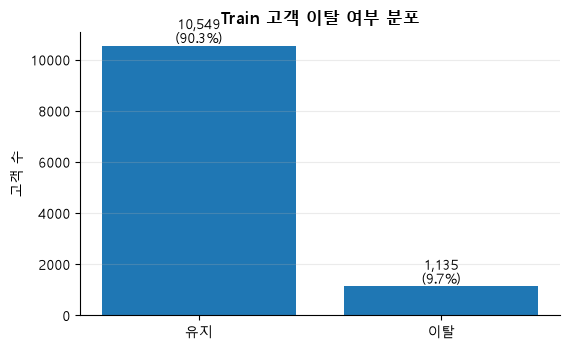

In [8]:
train_churn_summary = (
    train_client[TARGET_COL]
    .value_counts()
    .sort_index()
    .rename_axis(TARGET_COL)
    .reset_index(name="고객 수")
)

train_churn_summary["상태"] = train_churn_summary[TARGET_COL].map({
    0: "유지",
    1: "이탈",
})
train_churn_summary["비율(%)"] = (
    train_churn_summary["고객 수"] / len(train_client) * 100
)

display(train_churn_summary[[TARGET_COL, "상태", "고객 수", "비율(%)"]])

plt.figure(figsize=(5.8, 3.6))
bars = plt.bar(
    train_churn_summary["상태"],
    train_churn_summary["고객 수"],
)
plt.title("Train 고객 이탈 여부 분포")
plt.ylabel("고객 수")
plt.grid(axis="y", alpha=0.25)

for bar, count, rate in zip(
    bars,
    train_churn_summary["고객 수"],
    train_churn_summary["비율(%)"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,.0f}\n({rate:.1f}%)",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

In [9]:
train_numeric_cols = client_continuous_cols + client_discrete_cols

print("[Train 고객 수치형 상세 통계]")
display(detailed_numeric_summary(train_client, train_numeric_cols))

print("\n[Train 가격 수치형 상세 통계]")
display(detailed_numeric_summary(train_price, price_numeric_cols))

print("\n[Train 고객 연속형 IQR 이상치 후보]")
display(
    potential_outlier_summary(
        train_client,
        client_continuous_cols,
    )
)

print("\n[Train 가격 IQR 이상치 후보]")
display(
    potential_outlier_summary(
        train_price,
        price_numeric_cols,
    )
)

[Train 고객 수치형 상세 통계]


,count,missing,nunique,mean,std,min,1%,25%,50%,75%,99%,max,skew,zero_rate(%),negative_count
변수,,,,,,,,,,,,,,,
cons_12m,11684,0,9219,"159,429.2308","571,752.7583",0.0000,22.6600,"5,609.0000","14,139.0000","41,121.5000","3,129,623.2500","6,207,104.0000",6.0285,0.8302,0
cons_gas_12m,11684,0,1716,"27,843.6234","163,052.7583",0.0000,0.0000,0.0000,0.0000,0.0000,"891,995.8600","4,154,590.0000",10.0092,82.0695,0
cons_last_month,11684,0,4225,"16,149.3389","64,088.3493",0.0000,0.0000,0.0000,813.0000,"3,435.0000","382,647.0000","771,203.0000",6.3784,33.6529,0
forecast_cons_12m,11684,0,11222,"1,868.7074","2,419.6078",0.0000,0.0000,488.3400,"1,099.4300","2,404.1825","9,264.2950","82,902.8300",7.7751,2.1825,0
forecast_cons_year,11684,0,3739,"1,426.4794","3,414.9819",0.0000,0.0000,0.0000,321.0000,"1,769.0000","11,428.3500","175,375.0000",17.3642,41.8521,0
forecast_meter_rent_12m,11684,0,3145,63.0600,65.9642,0.0000,0.0000,16.1800,18.7250,131.0200,330.6880,599.3100,1.4376,4.9469,0
forecast_price_energy_off_peak,11684,0,479,0.1373,0.0247,0.0000,0.0925,0.1163,0.1432,0.1463,0.2087,0.2740,-0.1713,0.1455,0
forecast_price_energy_peak,11684,0,303,0.0507,0.0490,0.0000,0.0000,0.0000,0.0841,0.0988,0.1305,0.1960,-0.0237,47.8432,0
forecast_price_pow_off_peak,11684,0,37,43.1437,4.5453,0.0000,40.6067,40.6067,44.3114,44.3114,58.9960,59.2664,-4.9047,0.6590,0



[Train 가격 수치형 상세 통계]


,count,missing,nunique,mean,std,min,1%,25%,50%,75%,99%,max,skew,zero_rate(%),negative_count
변수,,,,,,,,,,,,,,,
price_off_peak_var,140113,0,1486,0.1424,0.0234,0.0000,0.1007,0.1266,0.1468,0.1516,0.2013,0.2807,-0.7226,0.1784,0
price_peak_var,140113,0,908,0.0522,0.0502,0.0000,0.0000,0.0000,0.0843,0.1020,0.1306,0.2298,-0.0324,47.5081,0
price_mid_peak_var,140113,0,527,0.0282,0.0360,0.0000,0.0000,0.0000,0.0000,0.0728,0.0914,0.1035,0.5070,61.8315,0
price_off_peak_fix,140113,0,54,42.9491,4.6549,0.0000,40.5660,40.7289,44.2669,44.4447,59.1735,59.4447,-5.2203,0.7530,0
price_peak_fix,140113,0,17,9.4643,12.1546,0.0000,0.0000,0.0000,0.0000,24.3396,36.3447,36.4907,0.5457,61.9314,0
price_mid_peak_fix,140113,0,17,6.0823,7.8139,0.0000,0.0000,0.0000,0.0000,16.2264,16.7244,17.4582,0.5220,61.9314,0



[Train 고객 연속형 IQR 이상치 후보]


,IQR,하한,상한,후보 수,후보 비율(%),비고
변수,,,,,,
cons_12m,"35,512.5000","-47,659.7500","94,390.2500","1,646.0000",14.0876,통계적 후보이며 자동 삭제하지 않음
cons_gas_12m,0.0000,NaN,NaN,NaN,NaN,IQR=0
cons_last_month,"3,435.0000","-5,152.5000","8,587.5000","1,641.0000",14.0448,통계적 후보이며 자동 삭제하지 않음
forecast_cons_12m,"1,915.8425","-2,385.4237","5,277.9462",840.0000,7.1893,통계적 후보이며 자동 삭제하지 않음
forecast_cons_year,"1,769.0000","-2,653.5000","4,422.5000","1,034.0000",8.8497,통계적 후보이며 자동 삭제하지 않음
forecast_meter_rent_12m,114.8400,-156.0800,303.2800,124.0000,1.0613,통계적 후보이며 자동 삭제하지 않음
forecast_price_energy_off_peak,0.0300,0.0713,0.1914,297.0000,2.5419,통계적 후보이며 자동 삭제하지 않음
forecast_price_energy_peak,0.0988,-0.1483,0.2471,0.0000,0.0000,통계적 후보이며 자동 삭제하지 않음
forecast_price_pow_off_peak,3.7047,35.0497,49.8684,289.0000,2.4735,통계적 후보이며 자동 삭제하지 않음



[Train 가격 IQR 이상치 후보]


,IQR,하한,상한,후보 수,후보 비율(%),비고
변수,,,,,,
price_off_peak_var,0.0250,0.0890,0.1892,3593,2.5644,통계적 후보이며 자동 삭제하지 않음
price_peak_var,0.1020,-0.1529,0.2549,0,0.0000,통계적 후보이며 자동 삭제하지 않음
price_mid_peak_var,0.0728,-0.1093,0.1821,0,0.0000,통계적 후보이며 자동 삭제하지 않음
price_off_peak_fix,3.7158,35.1551,50.0184,3537,2.5244,통계적 후보이며 자동 삭제하지 않음
price_peak_fix,24.3396,-36.5094,60.8490,0,0.0000,통계적 후보이며 자동 삭제하지 않음
price_mid_peak_fix,16.2264,-24.3396,40.5660,0,0.0000,통계적 후보이며 자동 삭제하지 않음


In [10]:
def target_rate_table(
    df: pd.DataFrame,
    column: str,
    target: str = TARGET_COL,
) -> pd.DataFrame:
    temp = df[[column, target]].copy()
    temp[column] = temp[column].fillna("<NA>").astype(str)

    result = (
        temp.groupby(column, dropna=False)[target]
        .agg(
            customer_count="size",
            churn_count="sum",
            churn_rate="mean",
        )
        .reset_index()
    )
    result["churn_rate(%)"] = result["churn_rate"] * 100

    return (
        result.drop(columns="churn_rate")
        .sort_values(
            ["churn_rate(%)", "customer_count"],
            ascending=[False, False],
        )
    )


for col in client_categorical_cols:
    print(f"\n[{col} 범주별 Train 이탈률]")
    display(target_rate_table(train_client, col))


[channel_sales 범주별 Train 이탈률]


,channel_sales,customer_count,churn_count,churn_rate(%)
4,foosdfpfkusacimwkcsosbicdxkicaua,5400,657,12.1667
7,usilxuppasemubllopkaafesmlibmsdf,1101,113,10.2634
0,MISSING,2975,234,7.8655
2,ewpakwlliwisiwduibdlfmalxowmwpci,710,52,7.3239
5,lmkebamcaaclubfxadlmueccxoimlema,1485,79,5.3199
6,sddiedcslfslkckwlfkdpoeeailfpeds,9,0,0.0000
1,epumfxlbckeskwekxbiuasklxalciiuu,3,0,0.0000
3,fixdbufsefwooaasfcxdxadsiekoceaa,1,0,0.0000



[origin_up 범주별 Train 이탈률]


,origin_up,customer_count,churn_count,churn_rate(%)
3,lxidpiddsbxsbosboudacockeimpuepw,5689,716,12.5857
2,ldkssxwpmemidmecebumciepifcamkci,2526,210,8.3135
0,MISSING,53,4,7.5472
1,kamkkxfxxuwbdslkwifmmcsiusiuosws,3414,205,6.0047
4,usapbepcfoloekilkwsdiboslwaxobdp,2,0,0.0000



[has_gas 범주별 Train 이탈률]


,has_gas,customer_count,churn_count,churn_rate(%)
0,f,9555,951,9.9529
1,t,2129,184,8.6426


In [11]:
def numeric_target_summary(
    df: pd.DataFrame,
    columns: list,
    target: str = TARGET_COL,
) -> pd.DataFrame:
    rows = []

    for col in columns:
        stay = pd.to_numeric(
            df.loc[df[target] == 0, col],
            errors="coerce",
        )
        churned = pd.to_numeric(
            df.loc[df[target] == 1, col],
            errors="coerce",
        )

        rows.append({
            "변수": col,
            "유지 평균": stay.mean(),
            "이탈 평균": churned.mean(),
            "평균 차이": churned.mean() - stay.mean(),
            "유지 중앙값": stay.median(),
            "이탈 중앙값": churned.median(),
            "중앙값 차이": churned.median() - stay.median(),
        })

    return pd.DataFrame(rows).set_index("변수")


display(
    numeric_target_summary(
        train_client,
        train_numeric_cols,
    )
)

train_spearman_corr = (
    train_client[train_numeric_cols + [TARGET_COL]]
    .corr(method="spearman")[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .rename("Spearman 상관계수")
    .to_frame()
)

print("\n[Train 수치형 변수와 churn의 Spearman 상관관계]")
display(train_spearman_corr)

,유지 평균,이탈 평균,평균 차이,유지 중앙값,이탈 중앙값,중앙값 차이
변수,,,,,,
cons_12m,"168,050.3891","79,301.8308","-88,748.5583","14,124.0000","14,384.0000",260.0000
cons_gas_12m,"29,805.6983","9,607.5639","-20,198.1344",0.0000,0.0000,0.0000
cons_last_month,"17,090.4901","7,402.0229","-9,688.4672",821.0000,776.0000,-45.0000
forecast_cons_12m,"1,857.3179","1,974.5644",117.2465,"1,097.2300","1,131.0000",33.7700
forecast_cons_year,"1,424.2842","1,446.8819",22.5977,318.0000,349.0000,31.0000
forecast_meter_rent_12m,62.1564,71.4581,9.3017,18.6200,19.9800,1.3600
forecast_price_energy_off_peak,0.1374,0.1363,-0.0010,0.1435,0.1426,-0.0008
forecast_price_energy_peak,0.0501,0.0554,0.0053,0.0839,0.0874,0.0035
forecast_price_pow_off_peak,43.1239,43.3284,0.2045,44.3114,44.3114,0.0000



[Train 수치형 변수와 churn의 Spearman 상관관계]


,Spearman 상관계수
margin_net_pow_ele,0.1062
margin_gross_pow_ele,0.1061
num_years_antig,-0.0832
forecast_meter_rent_12m,0.0394
forecast_price_energy_peak,0.0385
pow_max,0.0364
forecast_price_energy_off_peak,-0.0341
forecast_price_pow_off_peak,-0.0280
net_margin,0.0248
cons_gas_12m,-0.0159


,관측 개월 수,고객 수,비율(%)
0,7,3,0.0257
1,9,5,0.0428
2,10,8,0.0685
3,11,49,0.4194
4,12,11619,99.4437


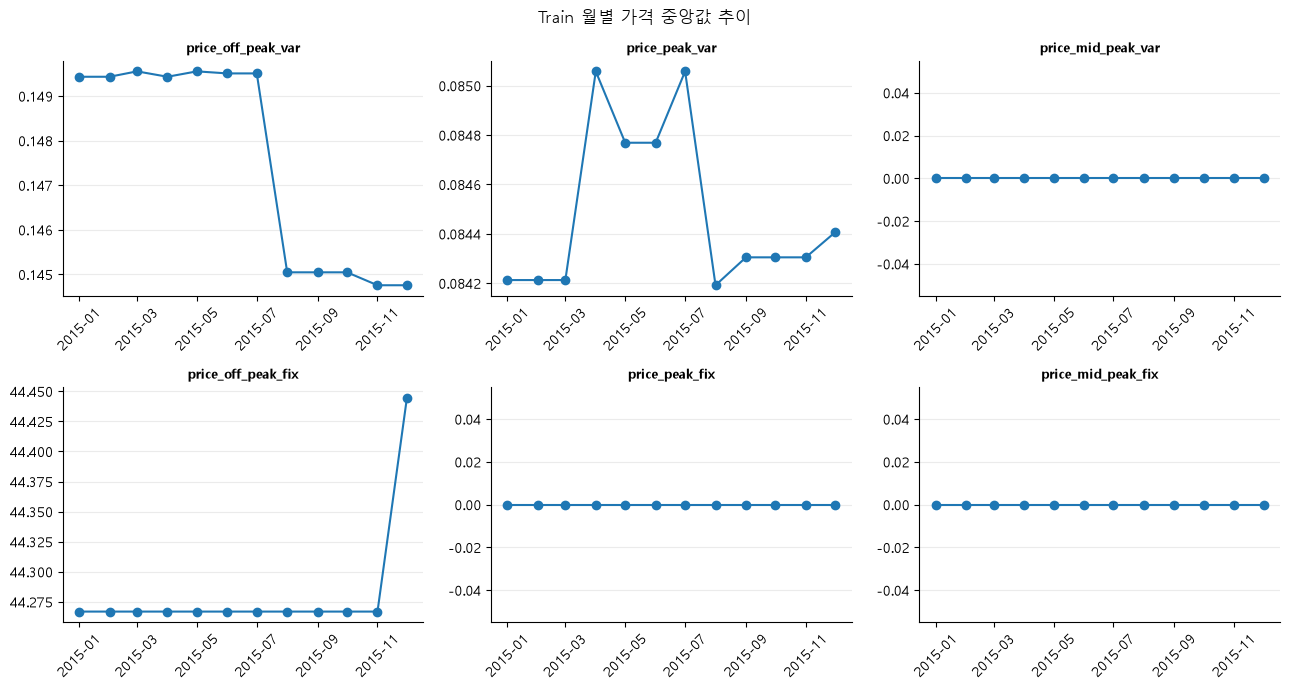

In [12]:
# 가격 이력 완전성은 Train에서만 확인
train_price_month_count = (
    train_price.groupby(ID_COL)["price_date"]
    .nunique()
    .rename("관측 개월 수")
)

price_month_summary = (
    train_price_month_count
    .value_counts()
    .sort_index()
    .rename_axis("관측 개월 수")
    .reset_index(name="고객 수")
)
price_month_summary["비율(%)"] = (
    price_month_summary["고객 수"]
    / price_month_summary["고객 수"].sum()
    * 100
)

display(price_month_summary)

train_monthly_price_median = (
    train_price.groupby("price_date")[price_numeric_cols]
    .median()
    .sort_index()
)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.ravel()

for ax, col in zip(axes, price_numeric_cols):
    ax.plot(
        train_monthly_price_median.index,
        train_monthly_price_median[col],
        marker="o",
    )
    ax.set_title(col, fontsize=9)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Train 월별 가격 중앙값 추이")
plt.tight_layout()
plt.show()

# 4. 예측 기준일 및 누수 점검

- 관측 종료일: 2015-12-31
- 예측 기준일: 2016-01-01
- 타깃 구간: 2016-01-01 이상 2016-04-01 미만

날짜 범위와 기준일 이후 기록은 Train에서만 확인한다.  
원본 날짜 컬럼은 최종 모델 입력에서 제외하고, 기준일 이전에 알 수 있는 정보로 계산한 파생변수만 사용한다.

In [13]:
MODEL_REFERENCE_DATE = pd.Timestamp("2016-01-01")
PREDICTION_END_DATE = MODEL_REFERENCE_DATE + pd.DateOffset(months=3)

date_leakage_audit = pd.DataFrame({
    "날짜 변수": client_date_cols,
    "Train 최소 날짜": [
        train_client[col].min()
        for col in client_date_cols
    ],
    "Train 최대 날짜": [
        train_client[col].max()
        for col in client_date_cols
    ],
    "기준일 이후 건수": [
        int((train_client[col] > MODEL_REFERENCE_DATE).sum())
        for col in client_date_cols
    ],
    "기준일 이후 비율(%)": [
        (train_client[col] > MODEL_REFERENCE_DATE).mean() * 100
        for col in client_date_cols
    ],
})

display(date_leakage_audit)

train_price_after_reference = int(
    (train_price["price_date"] >= MODEL_REFERENCE_DATE).sum()
)

print("예측 기준일:", MODEL_REFERENCE_DATE.date())
print(
    "예측 구간:",
    MODEL_REFERENCE_DATE.date(),
    "이상",
    PREDICTION_END_DATE.date(),
    "미만",
)
print(
    "Train 가격 데이터 중 예측 기준일 이후 행:",
    train_price_after_reference,
)

assert train_price_after_reference == 0

,날짜 변수,Train 최소 날짜,Train 최대 날짜,기준일 이후 건수,기준일 이후 비율(%)
0,date_activ,2003-06-05,2013-11-08,0,0.0000
1,date_end,2016-01-28,2017-06-13,11684,100.0000
2,date_modif_prod,2003-06-05,2016-01-29,50,0.4279
3,date_renewal,2013-06-26,2016-01-28,732,6.2650


예측 기준일: 2016-01-01
예측 구간: 2016-01-01 이상 2016-04-01 미만
Train 가격 데이터 중 예측 기준일 이후 행: 0


### 누수 판단 원칙

`date_end`는 기준일 이전에 등록된 **계약 종료 예정일**이라는 전제에서  
`contract_end_within_3m` 계산에 사용한다.

`forecast_*`, `imp_cons`, `margin_*` 변수도 기준일 시점에 이미 생성되어 조회 가능하다는 전제에서 사용한다.  
원천 시스템 확인 결과 사후 생성된 값이라면 모델 입력에서 제거해야 한다.

# 5. 검증된 파생변수 생성

고객 데이터에서는 다음 두 파생변수만 생성한다.

1. `contract_end_within_3m`: 예측 구간 안에 계약 종료가 예정되어 있는지
2. `recent_consumption_change_log`: 최근 한 달 소비량과 지난 12개월 월평균 소비량의 로그 차이

`forecast_consumption_change_rate`는 `forecast_cons_12m`과 `cons_12m`의 단위 일치가 확인되지 않았고,  
가격 변화와 이탈의 관계를 확인하려는 프로젝트 핵심 주제에도 직접적이지 않아 제거한다.

In [14]:
def safe_ratio(
    numerator: pd.Series,
    denominator: pd.Series,
) -> pd.Series:
    numerator = pd.to_numeric(numerator, errors="coerce")
    denominator = pd.to_numeric(denominator, errors="coerce")

    result = numerator / denominator.replace(0, np.nan)
    return result.replace([np.inf, -np.inf], np.nan)


def binary_with_missing(
    condition: pd.Series,
    source: pd.Series,
) -> pd.Series:
    return pd.Series(
        np.where(source.isna(), np.nan, condition.astype(float)),
        index=source.index,
        dtype="float64",
    )


# 로그 파생변수 채택 여부는 Train에서만 검증
train_consumption_check = pd.DataFrame({
    "변수": ["cons_12m", "cons_last_month"],
    "최솟값": [
        pd.to_numeric(train_client["cons_12m"], errors="coerce").min(),
        pd.to_numeric(train_client["cons_last_month"], errors="coerce").min(),
    ],
    "음수 개수": [
        int(
            (
                pd.to_numeric(
                    train_client["cons_12m"],
                    errors="coerce",
                ) < 0
            ).sum()
        ),
        int(
            (
                pd.to_numeric(
                    train_client["cons_last_month"],
                    errors="coerce",
                ) < 0
            ).sum()
        ),
    ],
})

display(train_consumption_check)

if (train_consumption_check["음수 개수"] > 0).any():
    raise ValueError(
        "Train 소비량에 음수가 있어 log1p 파생변수를 사용할 수 없습니다."
    )


def create_client_features(
    df: pd.DataFrame,
    reference_date: pd.Timestamp = MODEL_REFERENCE_DATE,
    prediction_end_date: pd.Timestamp = PREDICTION_END_DATE,
) -> pd.DataFrame:
    result = df.copy()

    # 빈 문자열만 실제 NaN으로 통일한다.
    # 문자열 MISSING은 정보 부재를 나타내는 하나의 범주로 유지한다.
    for col in client_categorical_cols:
        result[col] = result[col].replace(
            r"^\s*$",
            np.nan,
            regex=True,
        )

    result["contract_end_within_3m"] = binary_with_missing(
        (result["date_end"] >= reference_date)
        & (result["date_end"] < prediction_end_date),
        result["date_end"],
    )

    cons_12m = pd.to_numeric(
        result["cons_12m"],
        errors="coerce",
    )
    cons_last_month = pd.to_numeric(
        result["cons_last_month"],
        errors="coerce",
    )
    recent_monthly_average = cons_12m / 12

    result["recent_consumption_change_log"] = (
        np.log1p(cons_last_month)
        - np.log1p(recent_monthly_average)
    )

    return result


train_client_fe = create_client_features(train_client)
test_client_fe = create_client_features(test_client)

assert len(train_client_fe) == len(train_client)
assert len(test_client_fe) == len(test_client)
assert train_client_fe.columns.tolist() == test_client_fe.columns.tolist()

client_feature_cols = [
    "contract_end_within_3m",
    "recent_consumption_change_log",
]

print("고객 데이터 파생변수:", client_feature_cols)
display(
    missing_summary(
        train_client_fe[client_feature_cols]
    )
)

,변수,최솟값,음수 개수
0,cons_12m,0,0
1,cons_last_month,0,0


고객 데이터 파생변수: ['contract_end_within_3m', 'recent_consumption_change_log']


,실제 NaN 수,실제 NaN 비율(%),의미상 결측 수,의미상 결측 비율(%)


# 6. 고객 단위 병합

월별 가격 데이터는 고객별 1행으로 집계한 후 고객 데이터와 병합한다.

가격 파생변수:

- 이전 9개월 평균 대비 최근 3개월 비첨두 에너지 가격 변화율
- 이전 9개월 평균 대비 최근 3개월 비첨두 계약전력 가격 변화율
- 최근 실제 가격 대비 향후 예상 비첨두 에너지 가격 변화율
- 최근 실제 가격 대비 향후 예상 비첨두 계약전력 가격 변화율

`price_data`를 월 단위 그대로 병합하지 않아 고객 행이 12배로 복제되는 문제를 방지한다.

In [15]:
PRICE_FEATURE_SPECS = {
    "price_off_peak_var": "off_peak_energy_recent_change_rate",
    "price_off_peak_fix": "off_peak_power_recent_change_rate",
}


def aggregate_price_features(
    price_df: pd.DataFrame,
    reference_date: pd.Timestamp = MODEL_REFERENCE_DATE,
    recent_months: int = 3,
) -> pd.DataFrame:
    required_cols = [
        ID_COL,
        "price_date",
        *PRICE_FEATURE_SPECS.keys(),
    ]

    work = price_df[required_cols].copy()
    work["price_date"] = pd.to_datetime(
        work["price_date"],
        errors="coerce",
    )
    work = (
        work.loc[work["price_date"] < reference_date]
        .sort_values([ID_COL, "price_date"])
        .copy()
    )

    recent_start_date = (
        reference_date - pd.DateOffset(months=recent_months)
    )
    recent_mask = work["price_date"] >= recent_start_date
    previous_mask = work["price_date"] < recent_start_date

    result = pd.DataFrame(
        index=work[ID_COL].drop_duplicates().sort_values()
    )
    result.index.name = ID_COL

    for source_col, feature_name in PRICE_FEATURE_SPECS.items():
        recent_mean = (
            work.loc[recent_mask]
            .groupby(ID_COL)[source_col]
            .mean()
        )
        previous_mean = (
            work.loc[previous_mask]
            .groupby(ID_COL)[source_col]
            .mean()
        )
        last_price = (
            work.groupby(ID_COL)[source_col]
            .last()
        )

        result[feature_name] = safe_ratio(
            recent_mean - previous_mean,
            previous_mean.abs(),
        )
        result[f"__{source_col}_last"] = last_price

    return result.reset_index()


train_price_agg = aggregate_price_features(train_price)
test_price_agg = aggregate_price_features(test_price)

assert train_price_agg[ID_COL].is_unique
assert test_price_agg[ID_COL].is_unique
assert set(train_price_agg[ID_COL]) == set(train_client[ID_COL])
assert set(test_price_agg[ID_COL]) == set(test_client[ID_COL])

price_feature_cols = list(PRICE_FEATURE_SPECS.values())
price_helper_cols = [
    f"__{col}_last"
    for col in PRICE_FEATURE_SPECS
]

print("가격 데이터 파생변수:", price_feature_cols)

가격 데이터 파생변수: ['off_peak_energy_recent_change_rate', 'off_peak_power_recent_change_rate']


In [16]:
def merge_client_with_price(
    client_df: pd.DataFrame,
    price_agg_df: pd.DataFrame,
) -> pd.DataFrame:
    before_rows = len(client_df)
    before_ids = set(client_df[ID_COL])

    merged = client_df.merge(
        price_agg_df,
        on=ID_COL,
        how="left",
        validate="one_to_one",
    )

    assert len(merged) == before_rows
    assert merged[ID_COL].is_unique
    assert set(merged[ID_COL]) == before_ids

    return merged


def create_cross_source_features(
    df: pd.DataFrame,
) -> pd.DataFrame:
    result = df.copy()

    result["forecast_off_peak_energy_change"] = safe_ratio(
        result["forecast_price_energy_off_peak"]
        - result["__price_off_peak_var_last"],
        result["__price_off_peak_var_last"].abs(),
    )

    result["forecast_off_peak_power_change"] = safe_ratio(
        result["forecast_price_pow_off_peak"]
        - result["__price_off_peak_fix_last"],
        result["__price_off_peak_fix_last"].abs(),
    )

    return result.drop(columns=price_helper_cols)


train_merged = merge_client_with_price(
    train_client_fe,
    train_price_agg,
)
test_merged = merge_client_with_price(
    test_client_fe,
    test_price_agg,
)

train_featured = create_cross_source_features(train_merged)
test_featured = create_cross_source_features(test_merged)

assert train_featured.columns.tolist() == test_featured.columns.tolist()
assert len(train_featured) == len(train_client)
assert len(test_featured) == len(test_client)

cross_feature_cols = [
    "forecast_off_peak_energy_change",
    "forecast_off_peak_power_change",
]

engineered_feature_cols = (
    client_feature_cols
    + price_feature_cols
    + cross_feature_cols
)

assert len(engineered_feature_cols) == 6
assert all(
    col in train_featured.columns
    for col in engineered_feature_cols
)

display(
    pd.DataFrame({
        "최종 파생변수": engineered_feature_cols,
    })
)

,최종 파생변수
0,contract_end_within_3m
1,recent_consumption_change_log
2,off_peak_energy_recent_change_rate
3,off_peak_power_recent_change_rate
4,forecast_off_peak_energy_change
5,forecast_off_peak_power_change


In [17]:
print("[Train 최종 파생변수 결측 현황]")
display(
    missing_summary(
        train_featured[engineered_feature_cols]
    )
)

train_engineered_numeric = (
    train_featured[engineered_feature_cols]
    .select_dtypes(include="number")
)

train_engineered_inf_rows = int(
    np.isinf(train_engineered_numeric).any(axis=1).sum()
)

print(
    "Train 최종 파생변수 중 무한대 포함 행:",
    train_engineered_inf_rows,
)

assert train_engineered_inf_rows == 0

engineered_target_corr = (
    train_featured[
        engineered_feature_cols + [TARGET_COL]
    ]
    .corr(method="spearman")[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .rename("Spearman 상관계수")
    .to_frame()
)

display(engineered_target_corr)

[Train 최종 파생변수 결측 현황]


,실제 NaN 수,실제 NaN 비율(%),의미상 결측 수,의미상 결측 비율(%)
forecast_off_peak_power_change,90,0.7703,0,0.0000
off_peak_power_recent_change_rate,84,0.7189,0,0.0000
forecast_off_peak_energy_change,22,0.1883,0,0.0000
off_peak_energy_recent_change_rate,16,0.1369,0,0.0000


Train 최종 파생변수 중 무한대 포함 행: 0


,Spearman 상관계수
off_peak_energy_recent_change_rate,-0.0417
forecast_off_peak_energy_change,-0.0390
forecast_off_peak_power_change,0.0178
recent_consumption_change_log,-0.0153
contract_end_within_3m,0.0139
off_peak_power_recent_change_rate,-0.0098


# 7. 명백한 중복 제거

이 단계에서는 모델 종류와 관계없이 제거해도 되는 항목만 정리한다.

- 고객 식별용 `id`: CSV에는 유지하지만 모델 Feature에서는 제외
- 타깃 `churn`: CSV에는 유지하지만 모델 Feature에서는 제외
- 원본 날짜 컬럼: 기준일 기반 파생변수 생성 후 모델 Feature에서 제외
- Train에서 사실상 동일하다고 확인된 마진 컬럼
- Train에서 값과 결측 위치가 완전히 같은 정확한 중복 컬럼

결측치 대체, 원-핫 인코딩, 스케일링, PCA는 수행하지 않는다.  
파생변수 계산 중 생긴 무한대만 NaN으로 통일하고 고객 행은 삭제하지 않는다.

In [18]:
# 총마진과 순마진이 사실상 같은지 Train에서만 판단
margin_equal_mask = np.isclose(
    train_featured["margin_gross_pow_ele"],
    train_featured["margin_net_pow_ele"],
    equal_nan=True,
)
margin_equal_rate = float(margin_equal_mask.mean())

KNOWN_REDUNDANT_COLS = []
if margin_equal_rate >= 0.999:
    KNOWN_REDUNDANT_COLS.append("margin_gross_pow_ele")

print(
    "Train에서 margin_gross_pow_ele과 "
    f"margin_net_pow_ele 동일 비율: {margin_equal_rate * 100:.4f}%"
)
print("수동 제외 컬럼:", KNOWN_REDUNDANT_COLS)


def find_exact_duplicate_columns(
    df: pd.DataFrame,
) -> dict:
    duplicate_map = {}
    columns = df.columns.tolist()

    for current_index, current_col in enumerate(columns):
        for previous_col in columns[:current_index]:
            if df[current_col].equals(df[previous_col]):
                duplicate_map[current_col] = previous_col
                break

    return duplicate_map


MODEL_EXCLUDE_COLS = [
    ID_COL,
    TARGET_COL,
    *client_date_cols,
    *KNOWN_REDUNDANT_COLS,
]

base_feature_columns = [
    col
    for col in train_featured.columns
    if col not in MODEL_EXCLUDE_COLS
]

X_train_final = train_featured[base_feature_columns].copy()
X_test_final = test_featured[base_feature_columns].copy()

exact_duplicate_map = find_exact_duplicate_columns(X_train_final)
exact_duplicate_cols = list(exact_duplicate_map)

if exact_duplicate_cols:
    X_train_final = X_train_final.drop(columns=exact_duplicate_cols)
    X_test_final = X_test_final.drop(columns=exact_duplicate_cols)

# 계산 과정에서 발생한 무한대만 실제 결측값으로 통일한다.
# 결측 행 삭제와 결측치 대체는 하지 않는다.
X_train_final = (
    X_train_final
    .replace([np.inf, -np.inf], np.nan)
    .reset_index(drop=True)
)
X_test_final = (
    X_test_final
    .replace([np.inf, -np.inf], np.nan)
    .reset_index(drop=True)
)

y_train_final = (
    train_featured[TARGET_COL]
    .astype("int8")
    .reset_index(drop=True)
)
y_test_final = (
    test_featured[TARGET_COL]
    .astype("int8")
    .reset_index(drop=True)
)

train_id_final = (
    train_featured[ID_COL]
    .astype(str)
    .reset_index(drop=True)
)
test_id_final = (
    test_featured[ID_COL]
    .astype(str)
    .reset_index(drop=True)
)

assert X_train_final.columns.tolist() == X_test_final.columns.tolist()
assert len(X_train_final) == len(y_train_final) == len(train_id_final)
assert len(X_test_final) == len(y_test_final) == len(test_id_final)

numeric_features = X_train_final.select_dtypes(
    include="number"
).columns.tolist()

categorical_features = X_train_final.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

unclassified_features = sorted(
    set(X_train_final.columns)
    - set(numeric_features)
    - set(categorical_features)
)

assert not unclassified_features

cleaning_summary = pd.DataFrame({
    "항목": [
        "수동 제외 컬럼",
        "Train에서 탐지된 정확한 중복 컬럼",
        "삭제한 Train 고객 행",
        "최종 Feature 수",
        "수치형 Feature 수",
        "범주형 Feature 수",
        "Train NaN 셀 수",
    ],
    "값": [
        ", ".join(KNOWN_REDUNDANT_COLS) or "없음",
        (
            ", ".join(
                f"{col} = {source}"
                for col, source in exact_duplicate_map.items()
            )
            if exact_duplicate_map
            else "없음"
        ),
        0,
        X_train_final.shape[1],
        len(numeric_features),
        len(categorical_features),
        int(X_train_final.isna().sum().sum()),
    ],
})

display(cleaning_summary)

print("\n[범주형 원본 유지 컬럼]")
display(pd.DataFrame({"범주형": categorical_features}))

print("\n[Train 최종 결측 컬럼]")
train_final_missing = (
    X_train_final.isna().sum()
    .loc[lambda s: s > 0]
    .sort_values(ascending=False)
    .rename("NaN 수")
    .to_frame()
)
display(
    train_final_missing
    if not train_final_missing.empty
    else "최종 Train Feature에 NaN이 없습니다."
)

Train에서 margin_gross_pow_ele과 margin_net_pow_ele 동일 비율: 99.9914%
수동 제외 컬럼: ['margin_gross_pow_ele']


,항목,값
0,수동 제외 컬럼,margin_gross_pow_ele
1,Train에서 탐지된 정확한 중복 컬럼,없음
2,삭제한 Train 고객 행,0
3,최종 Feature 수,25
4,수치형 Feature 수,22
5,범주형 Feature 수,3
6,Train NaN 셀 수,212



[범주형 원본 유지 컬럼]


,범주형
0,channel_sales
1,has_gas
2,origin_up



[Train 최종 결측 컬럼]


,NaN 수
forecast_off_peak_power_change,90
off_peak_power_recent_change_rate,84
forecast_off_peak_energy_change,22
off_peak_energy_recent_change_rate,16


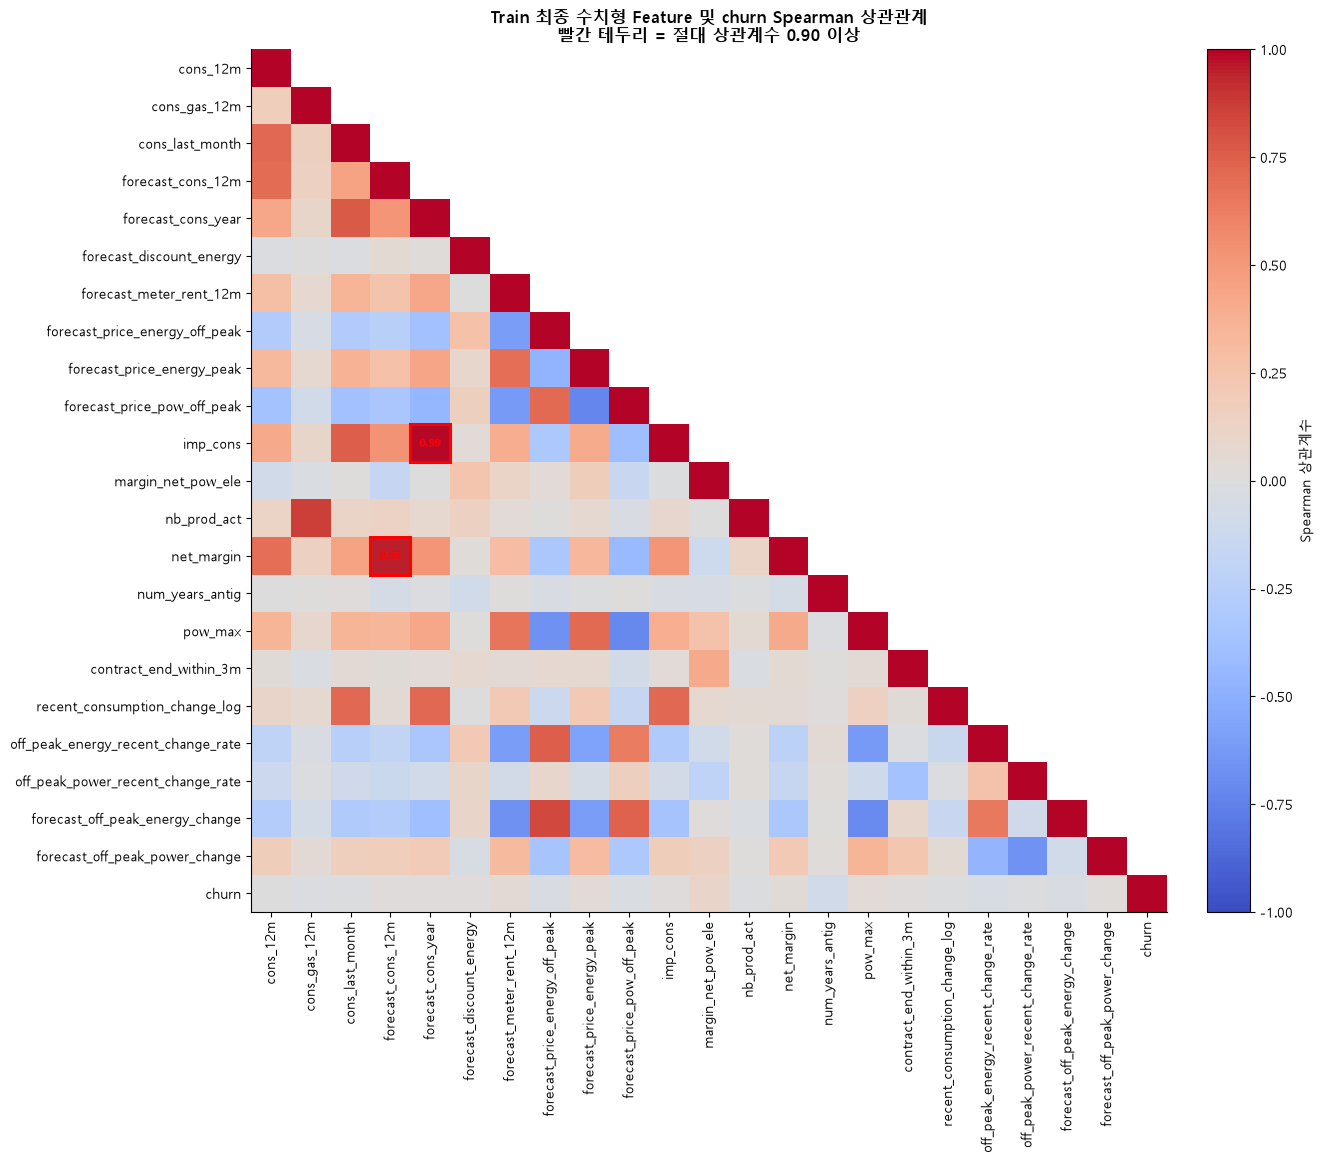

절대 Spearman 상관계수 0.90 이상 조합 수: 2


In [19]:
HIGH_CORR_THRESHOLD = 0.90

corr_frame = pd.concat(
    [
        X_train_final[numeric_features],
        y_train_final.rename(TARGET_COL),
    ],
    axis=1,
)

full_spearman_corr = corr_frame.corr(method="spearman")

mask = np.triu(
    np.ones_like(full_spearman_corr, dtype=bool),
    k=1,
)
shown_corr = np.ma.array(
    full_spearman_corr.to_numpy(),
    mask=mask,
)

fig_size = max(12, len(full_spearman_corr) * 0.58)
fig, ax = plt.subplots(
    figsize=(fig_size, fig_size * 0.88)
)

image = ax.imshow(
    shown_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto",
)

ax.set_xticks(range(len(full_spearman_corr.columns)))
ax.set_xticklabels(
    full_spearman_corr.columns,
    rotation=90,
)
ax.set_yticks(range(len(full_spearman_corr.index)))
ax.set_yticklabels(full_spearman_corr.index)
ax.set_title(
    "Train 최종 수치형 Feature 및 churn Spearman 상관관계\n"
    "빨간 테두리 = 절대 상관계수 0.90 이상"
)

high_corr_count = 0

for row in range(len(full_spearman_corr)):
    for col in range(row):
        value = full_spearman_corr.iat[row, col]

        if pd.notna(value) and abs(value) >= HIGH_CORR_THRESHOLD:
            ax.add_patch(
                Rectangle(
                    (col - 0.5, row - 0.5),
                    1,
                    1,
                    fill=False,
                    edgecolor="red",
                    linewidth=2.2,
                )
            )
            ax.text(
                col,
                row,
                f"{value:.2f}",
                ha="center",
                va="center",
                color="red",
                fontsize=
                8,
                fontweight="bold",
            )
            high_corr_count += 1

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)
colorbar.set_label("Spearman 상관계수")

plt.tight_layout()
plt.show()

print(
    f"절대 Spearman 상관계수 "
    f"{HIGH_CORR_THRESHOLD:.2f} 이상 조합 수:",
    high_corr_count,
)

# 8. 범주형은 원본 상태로 `train.csv`, `test.csv` 저장

최종 CSV에는 다음 형태로 저장한다.

- `id`: 예측 결과를 고객과 연결하기 위해 유지
- 수치형 원본·파생변수: 원래 단위 유지
- 범주형 변수: 문자열 상태 유지
- `churn`: 마지막 컬럼
- NaN: 그대로 유지
- 원-핫 인코딩·StandardScaler·PCA: 미적용

이후 모델링 Pipeline에서 각 교차검증 Fold의 학습 부분에만 전처리기를 fit한다.

In [20]:
train_result = pd.concat(
    [
        train_id_final.rename(ID_COL),
        X_train_final,
        y_train_final.rename(TARGET_COL),
    ],
    axis=1,
)

test_result = pd.concat(
    [
        test_id_final.rename(ID_COL),
        X_test_final,
        y_test_final.rename(TARGET_COL),
    ],
    axis=1,
)

assert train_result.columns.tolist() == test_result.columns.tolist()
assert train_result[ID_COL].is_unique
assert test_result[ID_COL].is_unique
assert train_result.columns[-1] == TARGET_COL
assert test_result.columns[-1] == TARGET_COL

RESULTS_DIR = DATA_DIR.parent / "results"
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TRAIN_RESULT_PATH = RESULTS_DIR / "train.csv"
TEST_RESULT_PATH = RESULTS_DIR / "test.csv"

train_result.to_csv(
    TRAIN_RESULT_PATH,
    index=False,
    encoding="utf-8-sig",
)

test_result.to_csv(
    TEST_RESULT_PATH,
    index=False,
    encoding="utf-8-sig",
)

export_summary = pd.DataFrame({
    "데이터": ["train.csv", "test.csv"],
    "행 수": [len(train_result), len(test_result)],
    "전체 컬럼 수": [
        train_result.shape[1],
        test_result.shape[1],
    ],
    "모델 Feature 수": [
        X_train_final.shape[1],
        X_test_final.shape[1],
    ],
    "저장 경로": [
        str(TRAIN_RESULT_PATH.resolve()),
        str(TEST_RESULT_PATH.resolve()),
    ],
})

display(export_summary)

print("범주형 원본 유지:", categorical_features)
print("원-핫 인코딩: 미적용")
print("StandardScaler: 미적용")
print("PCA: 미적용")
print("결측치 대체: 미적용")

,데이터,행 수,전체 컬럼 수,모델 Feature 수,저장 경로
0,train.csv,11684,27,25,C:\SKN_AI\SKN33_2_4team_project\data\results\t...
1,test.csv,2922,27,25,C:\SKN_AI\SKN33_2_4team_project\data\results\t...


범주형 원본 유지: ['channel_sales', 'has_gas', 'origin_up']
원-핫 인코딩: 미적용
StandardScaler: 미적용
PCA: 미적용
결측치 대체: 미적용


## 완료

이 노트북에서 생성한 `train.csv`, `test.csv`는 모든 후보 모델이 공통으로 사용하는 **전처리 이전의 모델링 원본 데이터**다.

다음 모델링 단계에서는 모델별 Pipeline을 따로 구성한다.

- DummyClassifier: 범주형 인코딩
- Logistic Regression: 범주형 인코딩 + 수치형 StandardScaler, PCA 적용 여부 비교
- Random Forest: 범주형 인코딩, 수치형 스케일링 불필요
- XGBoost / LightGBM: 범주형 인코딩, 수치형 스케일링 불필요

결측치가 존재하면 각 Pipeline의 Train Fold 안에서 대체 방법을 학습한다.

In [21]:
import pandas as pd
import numpy as np

train = pd.read_csv("../data/results/train.csv")
test = pd.read_csv("../data/results/test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("Train 중복 행:", train.duplicated().sum())
print("Test 중복 행:", test.duplicated().sum())

print("Train ID 중복:", train["id"].duplicated().sum())
print("Test ID 중복:", test["id"].duplicated().sum())

print(
    "Train/Test ID 중복:",
    len(set(train["id"]) & set(test["id"]))
)

print(
    "Train 무한대:",
    np.isinf(train.select_dtypes(include=np.number)).sum().sum()
)

print(
    "Test 무한대:",
    np.isinf(test.select_dtypes(include=np.number)).sum().sum()
)

Train shape: (11684, 27)
Test shape: (2922, 27)
Train 중복 행: 0
Test 중복 행: 0
Train ID 중복: 0
Test ID 중복: 0
Train/Test ID 중복: 0
Train 무한대: 0
Test 무한대: 0


In [22]:
train_missing = train.isna().sum()
test_missing = test.isna().sum()

print("[Train 결측 컬럼]")
print(train_missing[train_missing > 0])

print("[Test 결측 컬럼]")
print(test_missing[test_missing > 0])

[Train 결측 컬럼]
off_peak_energy_recent_change_rate    16
off_peak_power_recent_change_rate     84
forecast_off_peak_energy_change       22
forecast_off_peak_power_change        90
dtype: int64
[Test 결측 컬럼]
off_peak_energy_recent_change_rate     4
off_peak_power_recent_change_rate     21
forecast_off_peak_energy_change        4
forecast_off_peak_power_change        22
dtype: int64
